In [5]:
pip install --upgrade pip

  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install --quiet openmeteo-requests requests-cache retry-requests numpy pandas matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install folium

   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/113.4 kB ? eta -:--:--
   --------------------- ----------------- 61.4/113.4 kB 812.7 kB/s eta 0:00:01
   ---------------------------------------  112.6/113.4 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  112.6/113.4 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  112.6/113.4 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  112.6/113.4 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  112.6/113.4 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  112.6/113.4 kB 1.1 MB/s eta 0:00:01
   -------------------------------------- 113.4/113.4 kB 286.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/90.4 kB ? eta -:--:--
   ---------------------------------------- 90.4/90.4 kB 5.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------- ----- 8.4/9.6 MB 47.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 35.3 MB/s  0:00:00
   ---------------------------------------- 0.0/38.7 MB ? eta -:--:--
   ---------------------- ----------------- 21.5/38.7 MB 112.9 MB/s eta 0:00:01
   ---------------------------------------  38.5/38.7 MB 111.3 MB/s eta 0:00:01
   ---------------------------------------- 38.7/38.7 MB 79.2 MB/s  0:00:00

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ----------------------

In [17]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [18]:
import openmeteo_requests
import pandas as pd
import numpy as np
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import plotly.express as px
import plotly.graph_objects as go
import folium
from datetime import datetime, timedelta
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import missingno as msno
#Configuración del cliente Open-Meteo
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=3, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

#Coordenadas de ciudades
ciudades = {
    "Bogotá": (4.7110, -74.0721),
    "Medellín": (6.2442, -75.5812),
    "Cali": (3.4516, -76.5320),
    "Barranquilla": (10.9685, -74.7813)
}

# Descarga de datos de clima y aire
df_list = []

for ciudad, (lat, lon) in ciudades.items():
    # Clima
    url_weather = "https://api.open-meteo.com/v1/forecast"
    params_weather = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ["temperature_2m", "precipitation", "wind_speed_10m", "wind_direction_10m",
                   "relative_humidity_2m","cloud_cover","boundary_layer_height","surface_pressure", "shortwave_radiation"],
        "past_days": 90
    }

    response_w = openmeteo.weather_api(url_weather, params=params_weather)[0]
    hourly_w = response_w.Hourly()

    df_weather = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(hourly_w.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly_w.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly_w.Interval()),
            inclusive="left"
        ),
        "temperature": hourly_w.Variables(0).ValuesAsNumpy(),
        "precipitation": hourly_w.Variables(1).ValuesAsNumpy(),
        "wind_speed": hourly_w.Variables(2).ValuesAsNumpy(),
        "wind_direction": hourly_w.Variables(3).ValuesAsNumpy(),
         "humidity": hourly_w.Variables(4).ValuesAsNumpy(),
        "cloud_cover":  hourly_w.Variables(5).ValuesAsNumpy(),
        "PBL":  hourly_w.Variables(6).ValuesAsNumpy(),
        "pressure": hourly_w.Variables(7).ValuesAsNumpy(),
        "radiation": hourly_w.Variables(8).ValuesAsNumpy()
    })

    #Calidad del Aire
    url_air = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params_air = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ["pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "ozone", "sulphur_dioxide","us_aqi"],
        "past_days": 90
    }

    response_a = openmeteo.weather_api(url_air, params=params_air)[0]
    hourly_a = response_a.Hourly()

    df_air = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(hourly_a.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly_a.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly_a.Interval()),
            inclusive="left"
        ),
        "pm2_5": hourly_a.Variables(0).ValuesAsNumpy(),
        "pm10": hourly_a.Variables(1).ValuesAsNumpy(),
        "co": hourly_a.Variables(2).ValuesAsNumpy(),
        "no2": hourly_a.Variables(3).ValuesAsNumpy(),
        "o3": hourly_a.Variables(4).ValuesAsNumpy(),
        "so2": hourly_a.Variables(5).ValuesAsNumpy(),
        "us_aqi": hourly_a.Variables(6).ValuesAsNumpy()
    })

    #Unión por fecha
    df = pd.merge_asof(df_weather.sort_values("date"), df_air.sort_values("date"), on="date")
    df["city"] = ciudad
    df_list.append(df)

#Unir todas las ciudades
df_full = pd.concat(df_list, ignore_index=True)
display(df_full)


,date,temperature,precipitation,wind_speed,wind_direction,humidity,cloud_cover,PBL,pressure,radiation,pm2_5,pm10,co,no2,o3,so2,us_aqi,city
0,2025-07-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.200001,25.799999,1051.0,23.200001,18.0,19.600000,40.503475,Bogotá
1,2025-07-23 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.100000,24.500000,1091.0,21.799999,17.0,19.900000,42.187500,Bogotá
2,2025-07-23 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.700001,22.000000,1049.0,19.900000,16.0,20.200001,42.777779,Bogotá
3,2025-07-23 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.200001,19.400000,993.0,18.200001,15.0,19.600000,42.951389,Bogotá
4,2025-07-23 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.600000,16.799999,947.0,17.000000,16.0,17.400000,42.812504,Bogotá
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9307,2025-10-27 19:00:00+00:00,29.700001,3.0,11.298495,247.520523,78.0,99.0,885.0,1004.019409,664.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Barranquilla
9308,2025-10-27 20:00:00+00:00,29.400000,3.0,11.525623,255.529663,78.0,99.0,580.0,1003.518127,498.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Barranquilla
9309,2025-10-27 21:00:00+00:00,29.150000,3.0,11.090103,256.865967,79.0,98.0,335.0,1003.416382,320.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Barranquilla
9310,2025-10-27 22:00:00+00:00,29.100000,0.7,9.904906,250.906403,79.0,99.0,225.0,1003.815247,153.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Barranquilla


Bloque A – Exploración Básica de los Datos

¿Cuántos registros erróneos o faltantes aparecen en los datos de las APIs?

¿Qué ciudades tienen las temperaturas promedio más altas y bajas del país durante el período analizado?

¿Cómo varía la humedad relativa y la velocidad del viento entre regiones?

¿Qué tan frecuente es la presencia de lluvia en cada ciudad?

Objetivo: demostrar comprensión de la calidad y estructura del dataset, y la necesidad de limpieza.

In [19]:
#Limpieza y control de calidad
print("Registros totales:", len(df_full))
display("Valores nulos por columna:\n", df_full.isna().sum())

#Eliminar filas con más de 3 nulos
df_clean = df_full.dropna(thresh=len(df_full.columns)-3)

#Filtrar valores
df_clean = df_clean[

    (df_clean["temperature"].between(-20, 50)) &          # Temperatura en °C (rango razonable)
    (df_clean["precipitation"].between(0, 500)) &         # Precipitación mm/h (500 mm/h sería extremo)
    (df_clean["wind_speed"].between(0, 216)) &              # Velocidad del viento m/s (~216 km/h máx.)
    (df_clean["wind_direction"].between(0, 360)) &        # Dirección del viento en grados
    (df_clean["humidity"].between(0, 100)) &               # %
    (df_clean["cloud_cover"].between(0, 100)) &            # %

    #Variables de calidad del aire
    (df_clean["pm2_5"].between(0, 500)) &                  # µg/m³
    (df_clean["pm10"].between(0, 600)) &                   # µg/m³
    (df_clean["co"].between(0, 5000)) &                    # µg/m³
    (df_clean["no2"].between(0, 400)) &                    # µg/m³
    (df_clean["o3"].between(0, 400)) &                     # µg/m³
    (df_clean["so2"].between(0, 500)) &                    # µg/m³
    (df_clean["us_aqi"].between(0, 500))

].copy()
display(df_clean)
print("Datos limpios:", len(df_clean))
print("Registros eliminados por errores:", len(df_weather) - len(df_clean))


Registros totales: 9312


'Valores nulos por columna:\n'

date                0
temperature       980
precipitation     980
wind_speed        980
wind_direction    980
humidity          980
cloud_cover       980
PBL               980
pressure          980
radiation         980
pm2_5             236
pm10              236
co                236
no2               236
o3                236
so2               236
us_aqi            232
city                0
dtype: int64

,date,temperature,precipitation,wind_speed,wind_direction,humidity,cloud_cover,PBL,pressure,radiation,pm2_5,pm10,co,no2,o3,so2,us_aqi,city
245,2025-08-02 05:00:00+00:00,10.303500,0.0,7.280550,81.469322,93.0,60.0,55.0,751.135986,0.0,13.2,13.3,1147.0,15.8,16.0,13.1,36.562492,Bogotá
246,2025-08-02 06:00:00+00:00,9.803500,0.0,8.209263,74.744827,94.0,85.0,60.0,750.527161,0.0,10.8,10.9,1070.0,15.2,16.0,11.3,35.590275,Bogotá
247,2025-08-02 07:00:00+00:00,9.403500,0.0,8.654986,73.072411,94.0,87.0,70.0,749.995422,0.0,8.8,8.8,898.0,15.4,16.0,9.9,34.722221,Bogotá
248,2025-08-02 08:00:00+00:00,9.403500,0.0,8.209263,74.744827,92.0,100.0,60.0,749.847351,0.0,7.5,7.6,682.0,16.0,16.0,8.8,33.888889,Bogotá
249,2025-08-02 09:00:00+00:00,9.103500,0.0,8.427383,70.016808,93.0,100.0,60.0,749.836670,0.0,6.6,6.7,582.0,16.1,16.0,8.1,33.177082,Bogotá
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9248,2025-10-25 08:00:00+00:00,26.650000,0.0,11.520000,180.000000,89.0,35.0,310.0,1006.189880,0.0,3.0,3.3,170.0,4.8,28.0,1.5,15.295137,Barranquilla
9249,2025-10-25 09:00:00+00:00,26.600000,0.0,11.901798,183.468155,89.0,39.0,285.0,1006.189270,0.0,2.5,2.7,159.0,4.2,28.0,1.3,15.225694,Barranquilla
9250,2025-10-25 10:00:00+00:00,26.500000,0.0,12.620554,183.270416,89.0,47.0,295.0,1006.687500,0.0,2.2,2.3,161.0,4.2,29.0,1.3,15.173610,Barranquilla
9251,2025-10-25 11:00:00+00:00,26.450001,0.0,12.979984,183.179764,90.0,55.0,305.0,1007.385437,4.0,2.3,2.3,171.0,4.5,31.0,1.3,15.138886,Barranquilla


Datos limpios: 8095
Registros eliminados por errores: -5767


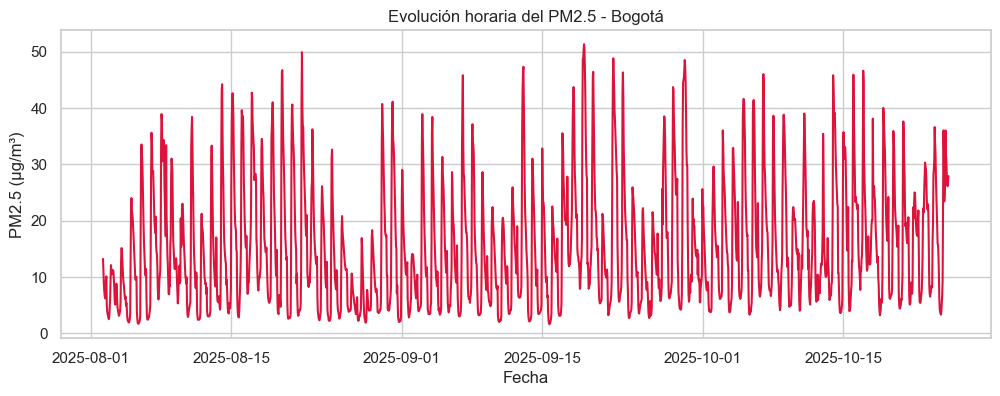

In [51]:
# EDA - Modelo 1️ Pronóstico de PM25

# A. Análisis temporal - Series de tiempo
# Ejemplo: trabajar con una sola ciudad (Bogotá) para visualizar
ciudad = "Bogotá"
df_city = df_clean[df_clean["city"] == ciudad].set_index("date")

#Serie temporal de PM2.5
plt.figure(figsize=(12, 4))
plt.plot(df_city.index, df_city["pm2_5"], color="crimson")
plt.title(f"Evolución horaria del PM2.5 - {ciudad}")
plt.xlabel("Fecha")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(True)
plt.show()

Partiendo que el PM2.5 es una medida de la cantidad de partículas finas suspendidas en el aire con un diámetro menor a 2.5 micrómetros, que son lo suficientemente pequeñas como para entrar en los pulmones y causar problemas de salud. Estas partículas provienen principalmente de fuentes como vehículos, industria, construcción, y quema de biomasa, entre otras.
El presente gráfico que muestra la evolución horaria de las concentraciones de PM2.5 en Bogotá entre agosto y octubre de 2025.
Hipotesis
¿Por qué pasa esto?

Las concentraciones de PM2.5 pueden variar significativamente por varias razones:

Condiciones Meteorológicas: La temperatura, humedad, y dirección del viento afectan la dispersión de partículas. En ciertos días, las condiciones pueden hacer que se acumulen más partículas en el aire.

Transporte Vehicular: Las ciudades con mucho tráfico tienden a tener mayores concentraciones de PM2.5 debido a las emisiones de los vehículos.

Actividades Industriales: Las fábricas y plantas de energía también emiten partículas finas en el aire.

Quemas al aire libre: Las quemas de basura o de áreas agrícolas pueden generar picos en las concentraciones de PM2.5.

Condiciones de Estancamiento del Aire: En ciertas épocas, como cuando hay baja presión o viento débil, las partículas se quedan suspendidas en el aire durante más tiempo, incrementando las concentraciones.
En conclusión hay muchas variciones en el día día , pero este gráfico no nos permite ver más allá de esto por eso vamos a presentar el gráfico del promedio de PM2.5, pero sabiendo como varía ahora por horas.

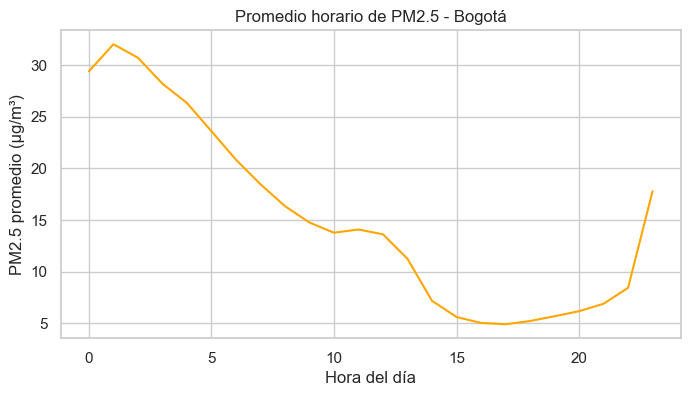

In [52]:
#Promedio por hora del día
df_city["hour"] = df_city.index.hour
mean_hour = df_city.groupby("hour")["pm2_5"].mean()

plt.figure(figsize=(8, 4))
sns.lineplot(x=mean_hour.index, y=mean_hour.values, color="orange")
plt.title(f"Promedio horario de PM2.5 - {ciudad}")
plt.xlabel("Hora del día")
plt.ylabel("PM2.5 promedio (µg/m³)")
plt.show()

00–04 h: valores altos (acumulación nocturna de contaminantes).

05–09 h: descenso progresivo mientras se disipa la inversión térmica.

10–16 h: mínimos del día, por mezcla atmosférica y ventilación solar.

18–23 h: incremento nocturno leve por tráfico y estabilidad del aire.

En conjunto, la curva muestra el pico nocturno temprano y el mínimo vespertino clásicos de zonas urbanas andinas con clima frío y vientos débiles en la noche.

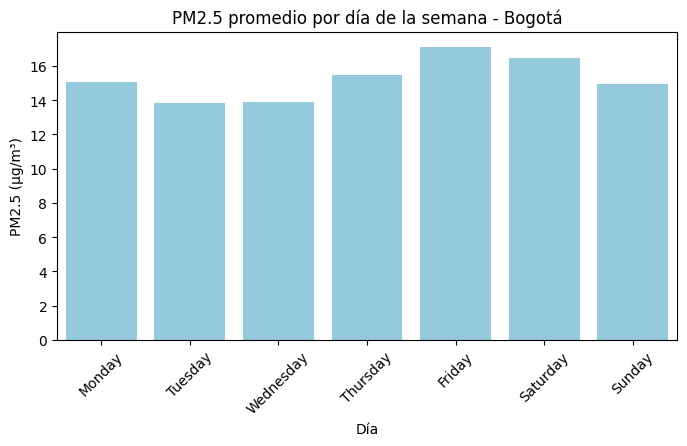

In [22]:
#Promedio por día de la semana
df_city["weekday"] = df_city.index.day_name()
mean_day = df_city.groupby("weekday")["pm2_5"].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
plt.figure(figsize=(8, 4))
sns.barplot(x=mean_day.index, y=mean_day.values, color="skyblue")
plt.title(f"PM2.5 promedio por día de la semana - {ciudad}")
plt.xlabel("Día")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.show()

Este gráfico ayuda a ver en qué días hay más contaminación. Entender esos patrones es útil para saber de dónde viene el problema y tomar decisiones que mejoren la salud pública y el ambiente en la ciudad.
Si los niveles de PM2.5 se mantienen parecidos durante la semana, sin importar la época del año, probablemente se deba a actividades humanas constantes como el tráfico o la quema de residuos. Pero si varían según la temporada, el clima o eventos puntuales podrían estar influyendo.

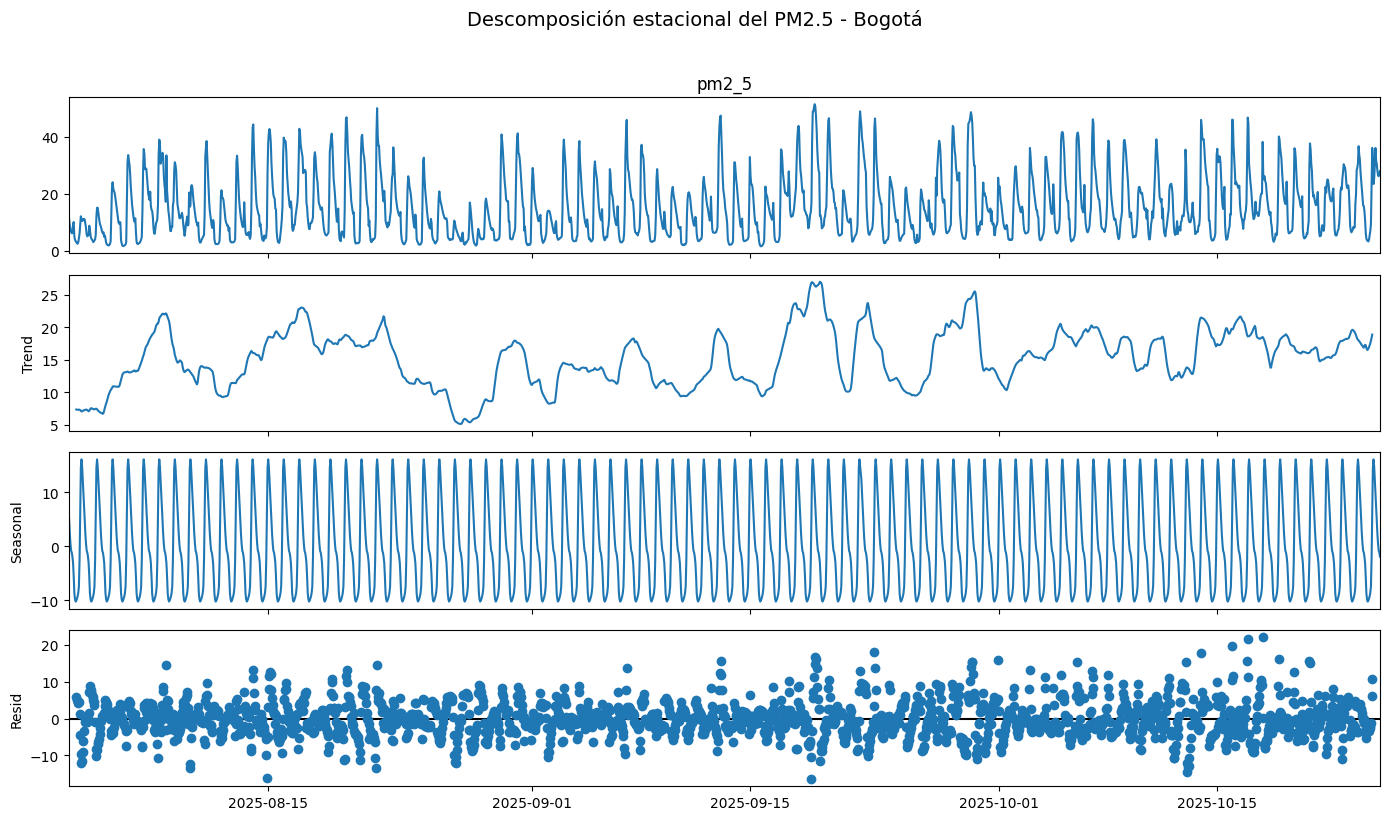

In [23]:
# Descomposición estacional
result = seasonal_decompose(df_city["pm2_5"], model='additive', period=24)

# Crear una figura más ancha (por ejemplo 14x8 pulgadas)
fig = result.plot()
fig.set_size_inches(14, 8)  # ancho=14, alto=8

# Ajustar título y espaciado
plt.suptitle(f"Descomposición estacional del PM2.5 - {ciudad}", y=1.02, fontsize=14)
plt.tight_layout()  # mejora la distribución
plt.show()

Estas gráficas se realiza una descomposición estacional de los niveles de PM2.5 en la ciudad, separando la serie en cuatro partes: la serie original, la tendencia a lo largo del tiempo, un patrón diario (cada 24 horas) y el ruido o variaciones no explicadas. Esto permite identificar si hay cambios sostenidos en la calidad del aire, reconocer patrones diarios (como picos en horas pico) y detectar anomalías o días atípicos.

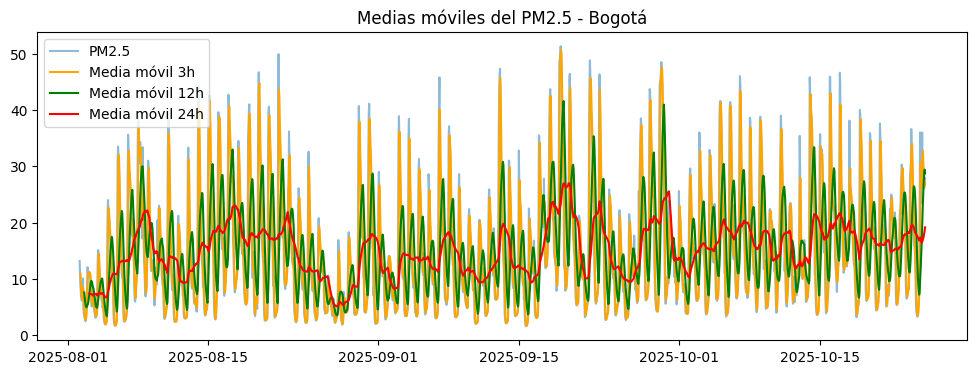

In [24]:
# --- Promedio móvil ---
plt.figure(figsize=(12, 4))
plt.plot(df_city.index, df_city["pm2_5"], label="PM2.5", alpha=0.5)
plt.plot(df_city["pm2_5"].rolling(3).mean(), label="Media móvil 3h", color="orange")
plt.plot(df_city["pm2_5"].rolling(12).mean(), label="Media móvil 12h", color="green")
plt.plot(df_city["pm2_5"].rolling(24).mean(), label="Media móvil 24h", color="red")
plt.legend()
plt.title(f"Medias móviles del PM2.5 - {ciudad}")
plt.show()

Este gráfico muestra cómo varían los niveles de PM2.5 en el tiempo y suaviza la serie con medias móviles de 3, 12 y 24 horas. Permite identificar mejor las tendencias a corto, medio y largo plazo, filtrando el ruido de las variaciones horarias.

A PERO CON OTROS CONTAMINANTES


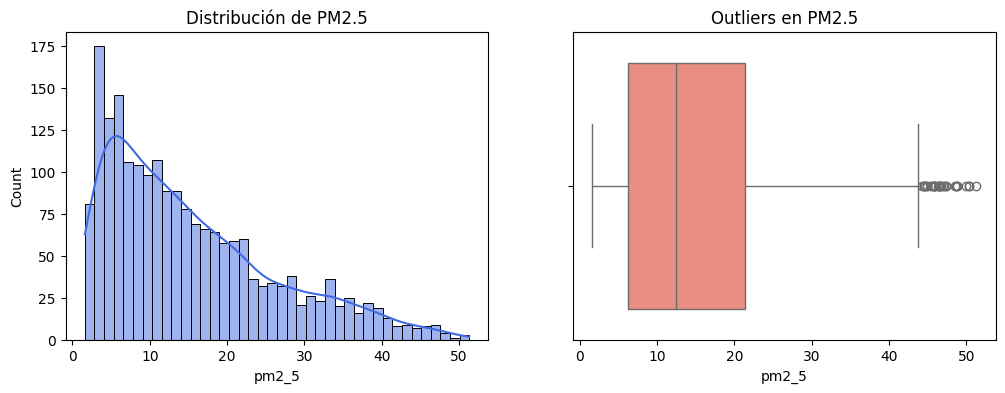

Media: 15.25052
Mediana: 12.4
Desviación estándar: 10.89749
Asimetría (skewness): 0.9638337
Curtosis: 0.19484274


In [28]:
# B. Distribución y outliers

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_city["pm2_5"], bins=40, ax=axes[0], color="royalblue", kde=True)
axes[0].set_title("Distribución de PM2.5")

sns.boxplot(x=df_city["pm2_5"], ax=axes[1], color="salmon")
axes[1].set_title("Outliers en PM2.5")

plt.show()

print("Media:", df_city["pm2_5"].mean())
print("Mediana:", df_city["pm2_5"].median())
print("Desviación estándar:", df_city["pm2_5"].std())
print("Asimetría (skewness):", df_city["pm2_5"].skew())
print("Curtosis:", df_city["pm2_5"].kurt())

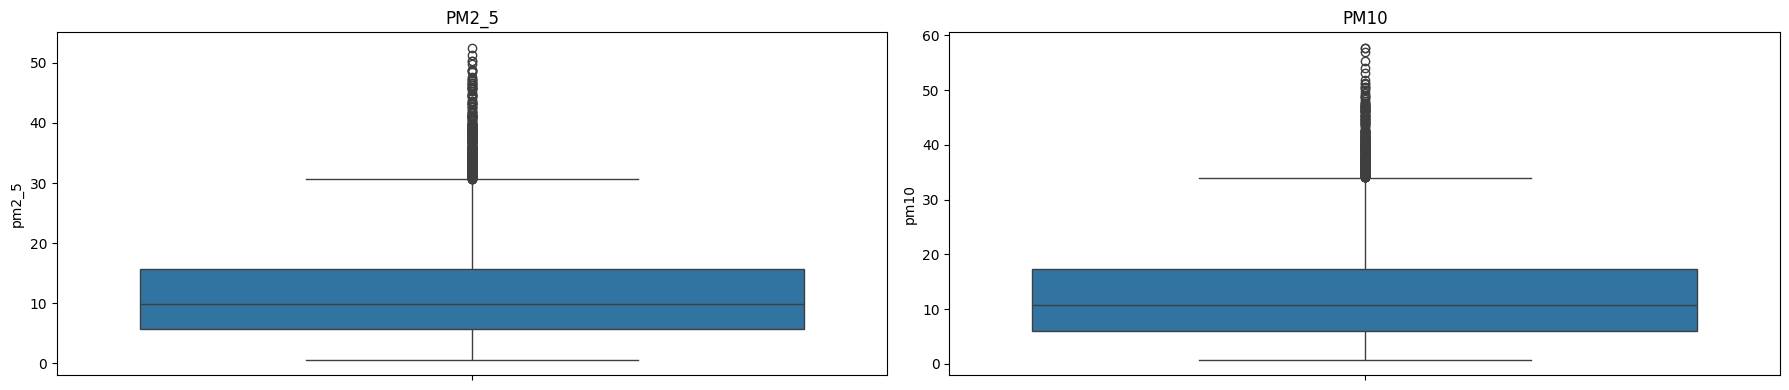

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18,4))
for i, col in enumerate(['pm2_5','pm10']):
    sns.boxplot(y=df_clean[col], ax=axes[i])
    axes[i].set_title(col.upper())
plt.tight_layout()
plt.show()


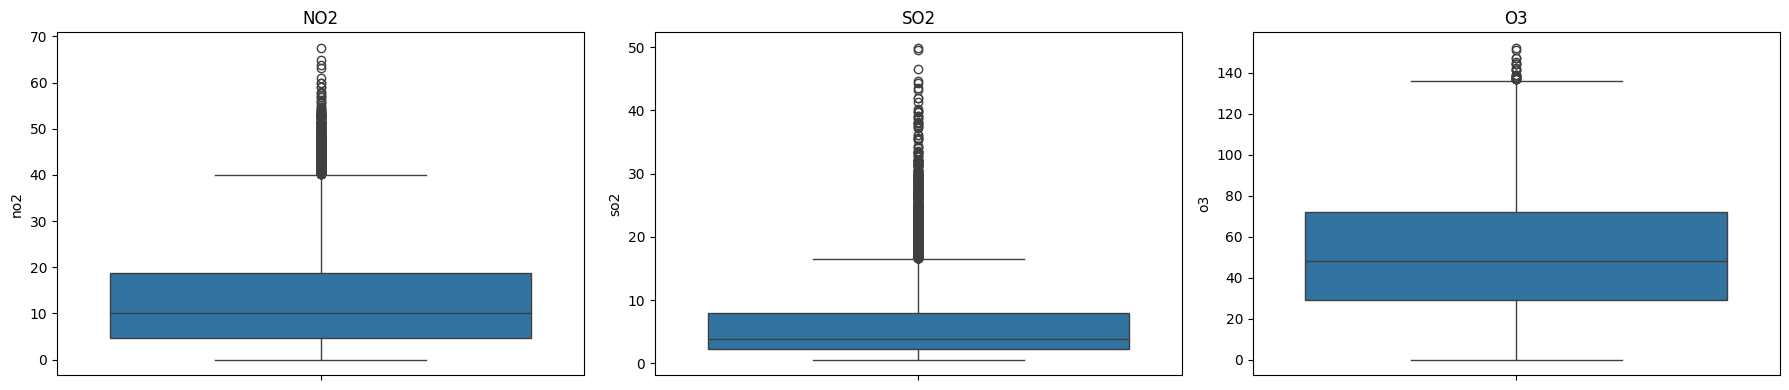

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for i, col in enumerate(['no2','so2','o3']):
    sns.boxplot(y=df_clean[col], ax=axes[i])
    axes[i].set_title(col.upper())
plt.tight_layout()
plt.show()


En los datos de PM2.5 de Bogotá, la distribución muestra que la mayoría de valores están concentrados en niveles bajos o moderados, pero hay algunos picos altos (outliers) que reflejan episodios de contaminación intensa. La media suele ser un poco mayor que la mediana, indicando un sesgo hacia valores altos. La desviación estándar muestra que la variación es notable, y la asimetría positiva confirma que hay más valores extremos hacia niveles altos de contaminación.

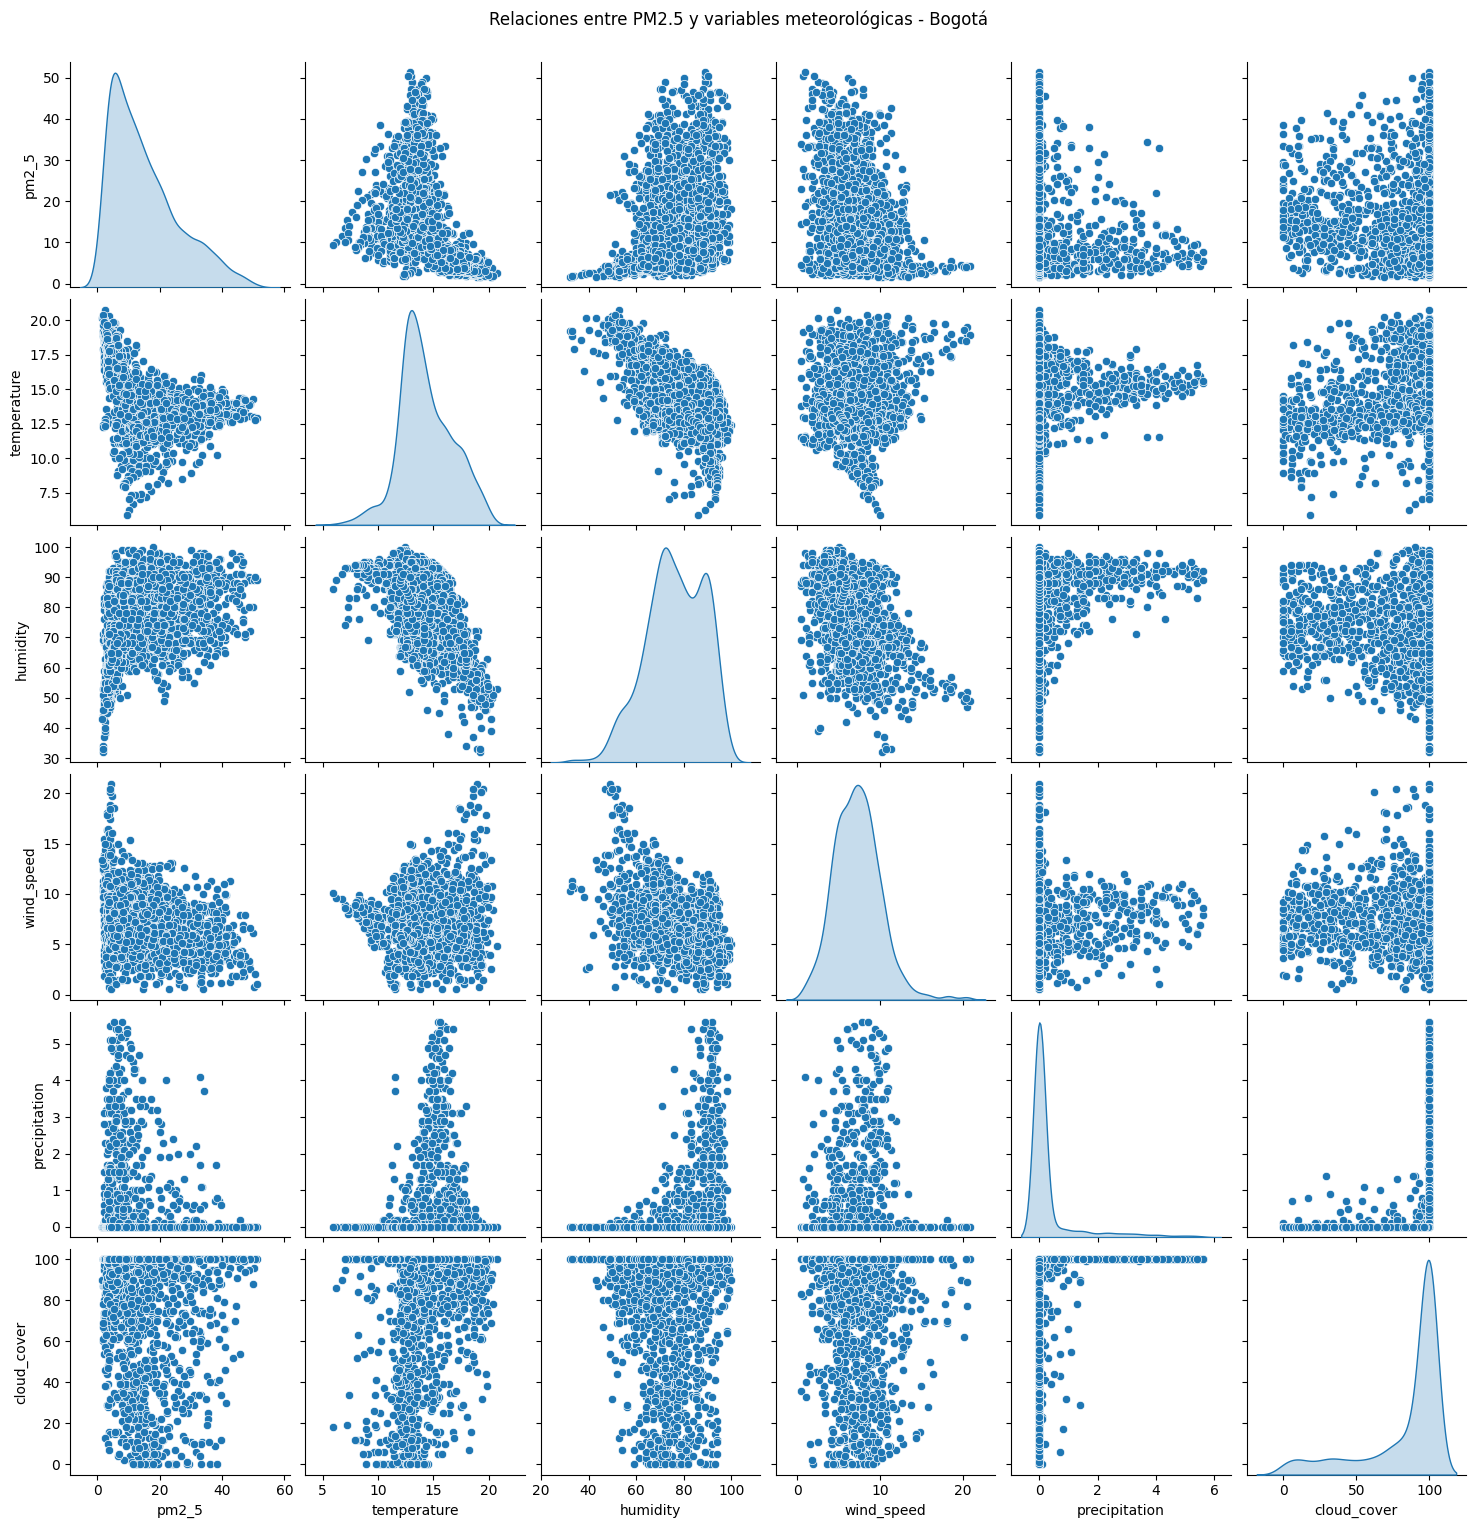

In [35]:
# C. Correlación con variables meteorológicas

vars_meteo = ["temperature", "humidity", "wind_speed", "precipitation", "cloud_cover"]
sns.pairplot(df_city[["pm2_5"] + vars_meteo].dropna(), diag_kind="kde")
plt.suptitle(f"Relaciones entre PM2.5 y variables meteorológicas - {ciudad}", y=1.02)
plt.show()



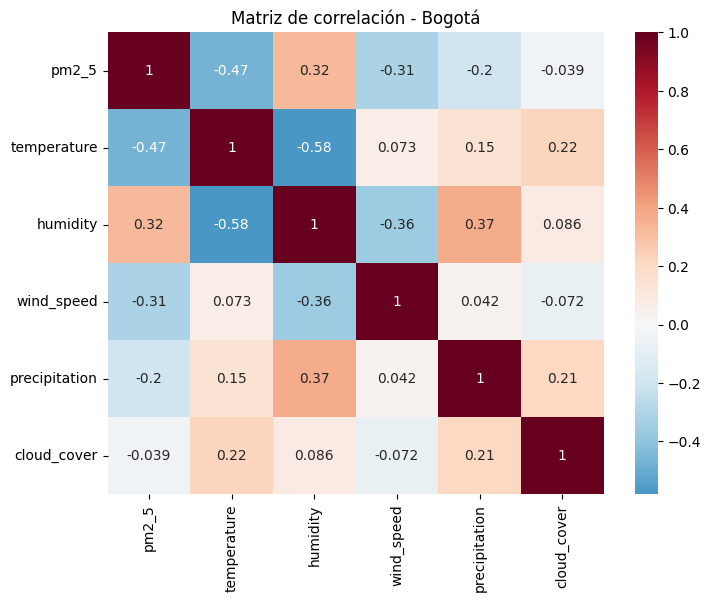

In [36]:
corr = df_city[["pm2_5"] + vars_meteo].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0)
plt.title(f"Matriz de correlación - {ciudad}")
plt.show()

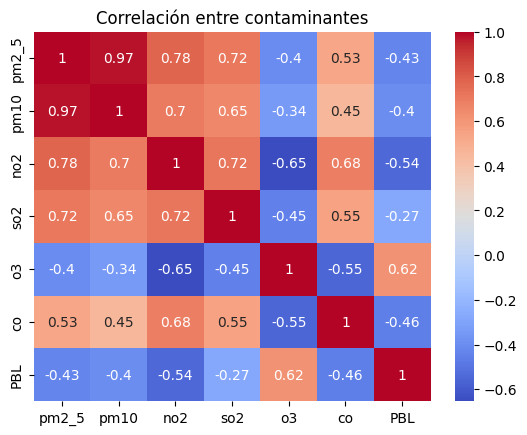

In [37]:
corr_poll = df_clean[['pm2_5','pm10','no2','so2','o3','co','PBL']].corr()
sns.heatmap(corr_poll, annot=True, cmap='coolwarm')
plt.title("Correlación entre contaminantes")
plt.show()


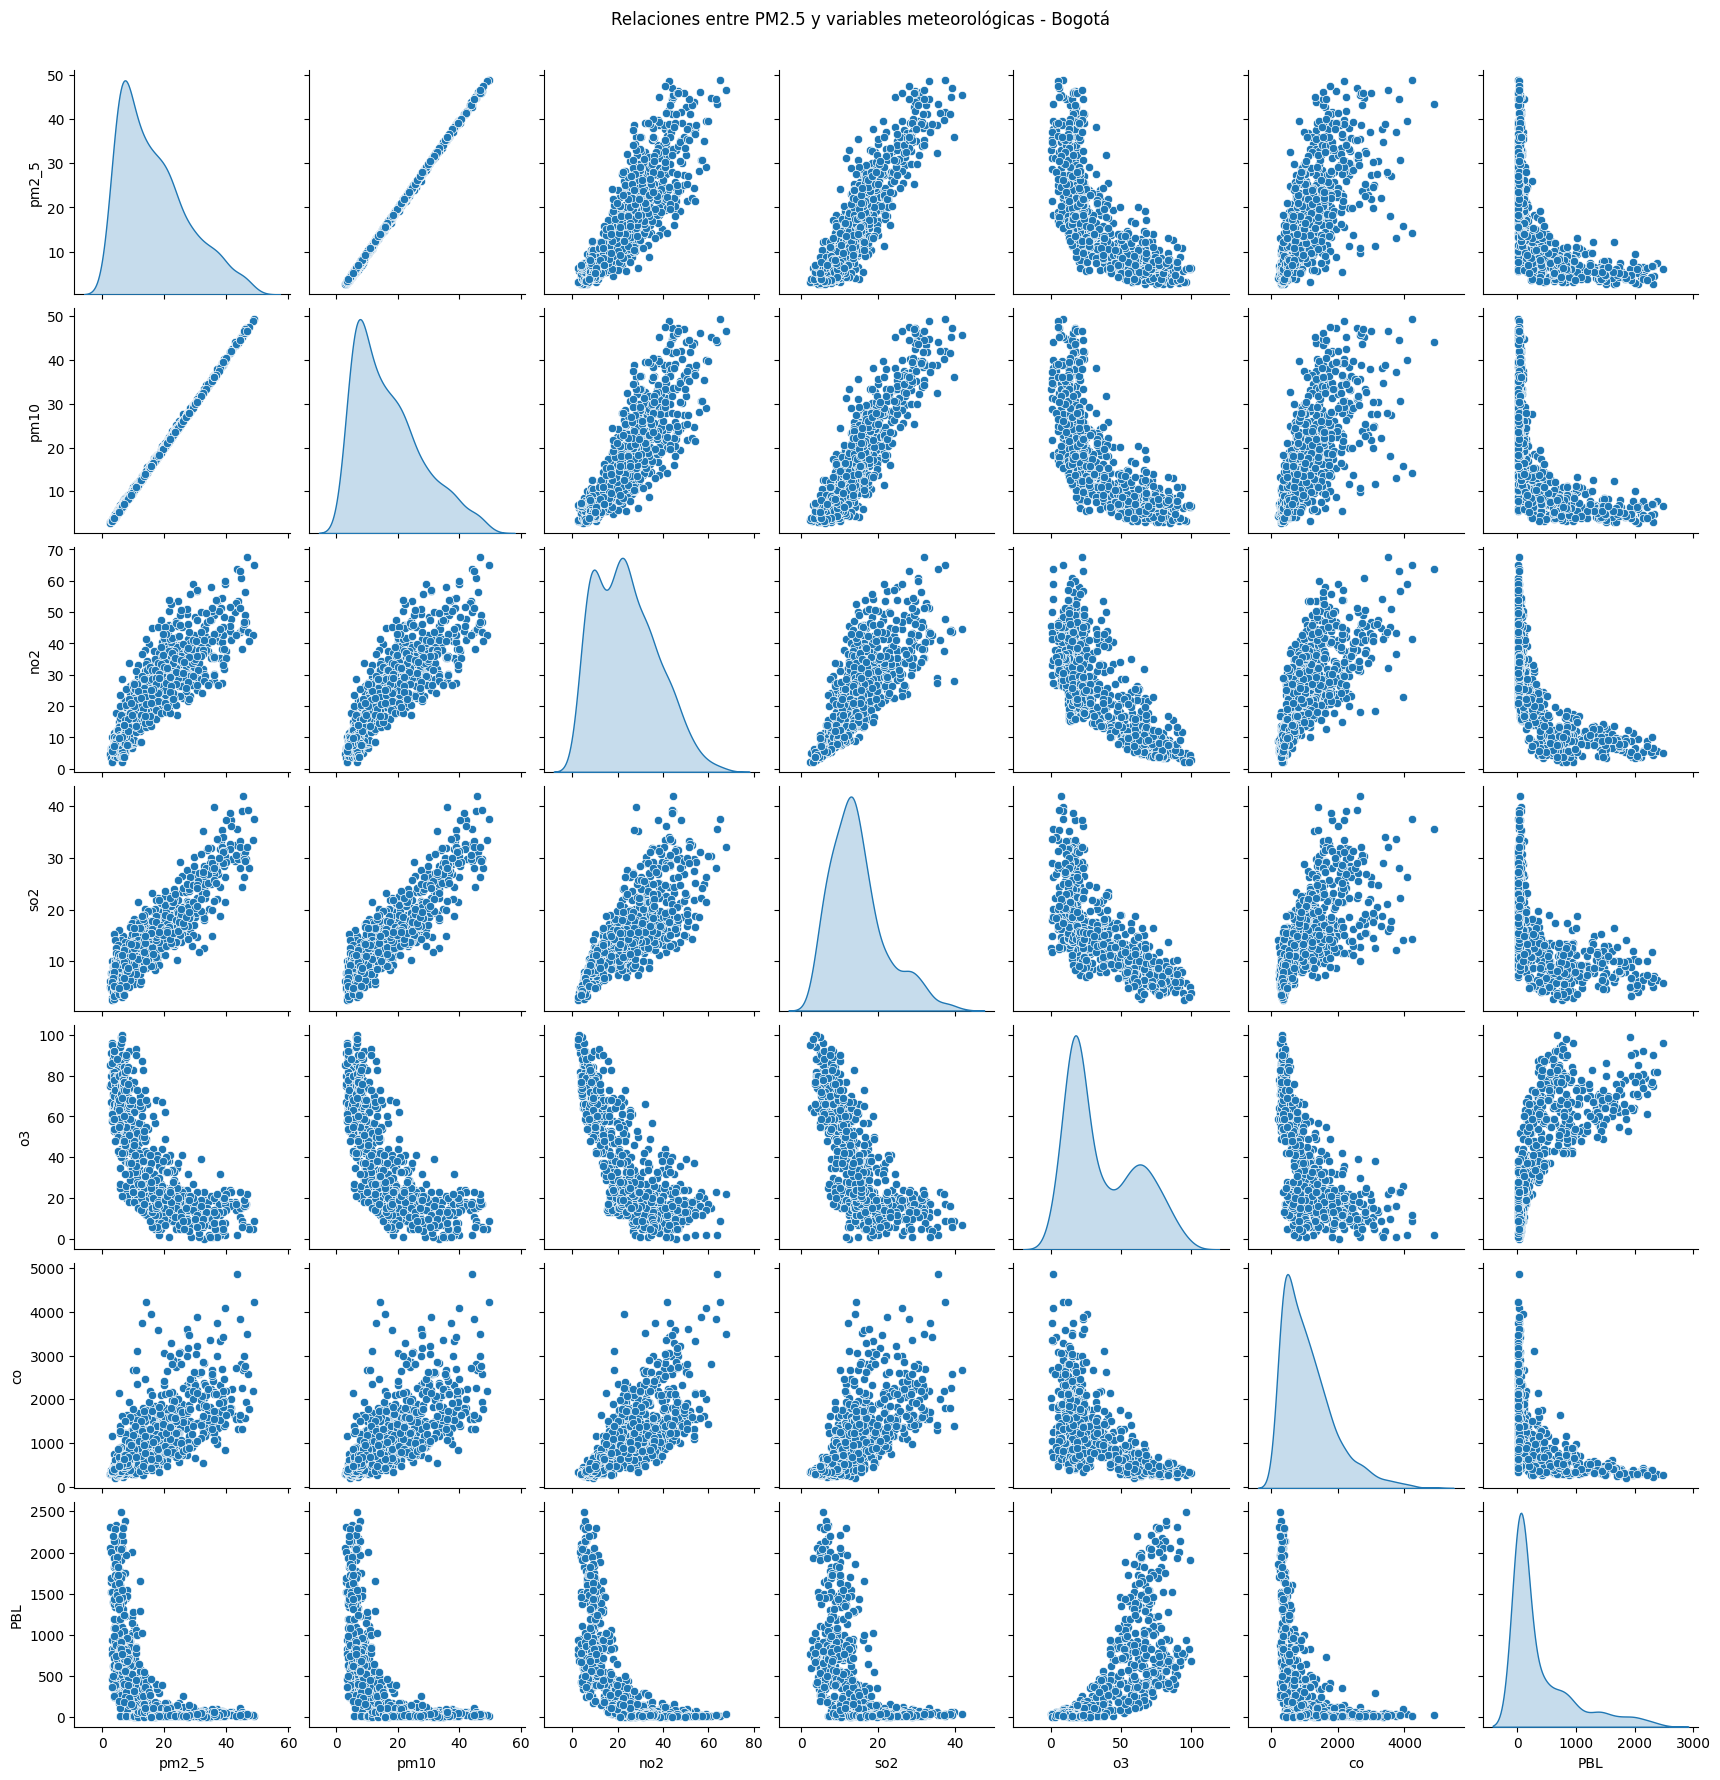

In [18]:

vars_meteo = ['pm10','no2','so2','o3','co','PBL']
sns.pairplot(df_city[["pm2_5"] + vars_meteo].dropna(), diag_kind="kde")
plt.suptitle(f"Relaciones entre PM2.5 y variables meteorológicas - {ciudad}", y=1.02)
plt.show()


PM2.5, PM10, NO2 y SO2: correlaciones positivas fuertes entre contaminantes → cuando uno aumenta, los demás también.

PM2.5 / PM10 vs. O3: correlación negativa → más ozono coincide con menos material particulado (efecto fotoquímico).

PM2.5 / PM10 vs. humedad: relación positiva moderada → alta humedad favorece acumulación de contaminantes.

PM2.5 / PM10 vs. PBL: relación negativa → cuando la capa límite atmosférica es baja, se concentra más contaminación.

NO2 y SO2: fuertemente relacionados (fuentes comunes, como tráfico o combustión).

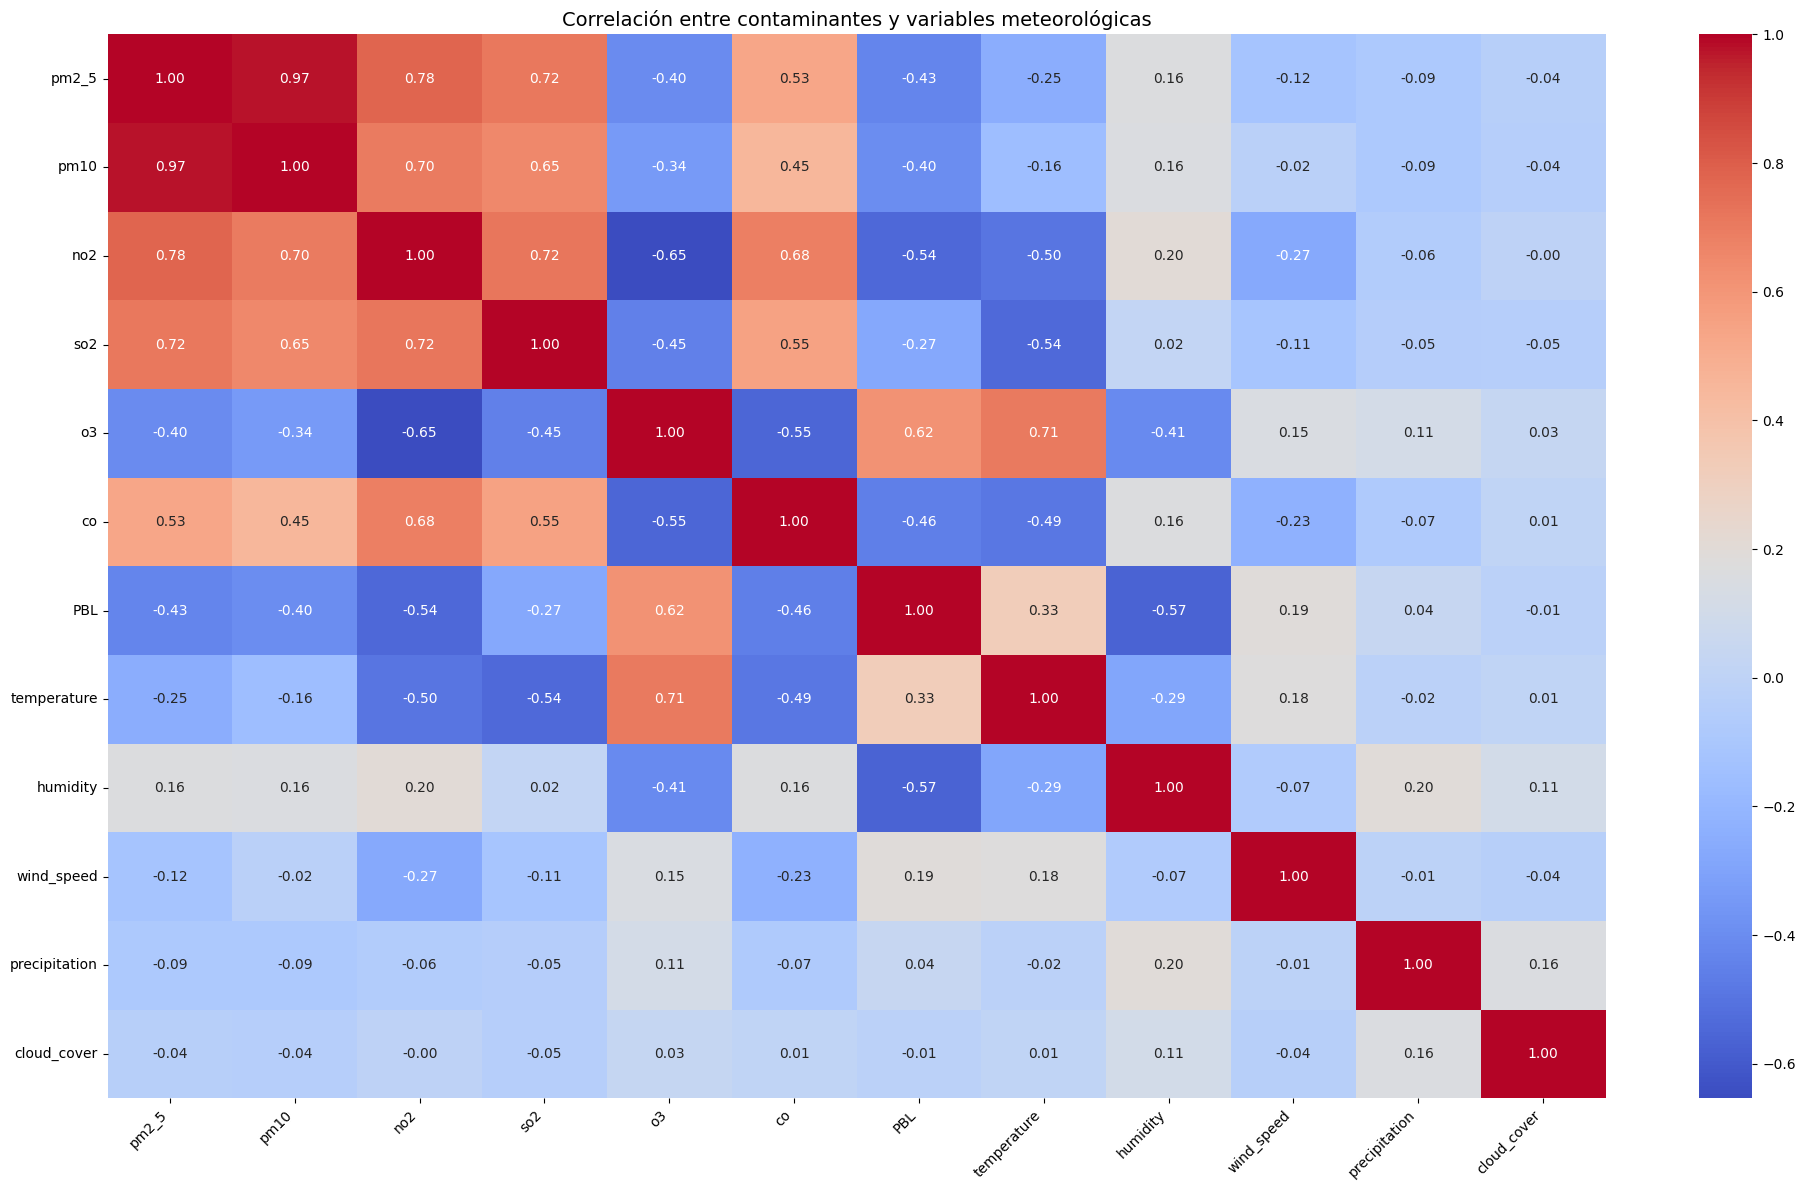

In [38]:
cols_corr = ['pm2_5','pm10','no2','so2','o3','co','PBL', 'temperature', 'humidity', 'wind_speed',
             'precipitation', 'cloud_cover']
plt.figure(figsize=(20, 12))
corr_poll_1 = df_clean[cols_corr].corr()
sns.heatmap(corr_poll_1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre contaminantes y variables meteorológicas", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



Se observa que Contaminantes primarios (PM2.5, PM10, NO2, SO2, CO) están fuertemente correlacionados entre sí, aumentando o disminuyendo juntos.

Ozono (O3) presenta correlaciones negativas con estos contaminantes, sugiriendo que cuando los contaminantes primarios suben, el ozono tiende a bajar, probablemente por reacciones químicas atmosféricas.

Variables meteorológicas: La temperatura y la capa límite planetaria (PBL) se asocian positivamente con el ozono, favoreciendo su formación en condiciones cálidas y con buena mezcla vertical.

Humedad tiene correlación negativa con ozono y poca influencia sobre otros contaminantes.

Velocidad del viento, precipitación y cobertura de nubes muestran poca correlación con los contaminantes.

Conclusión:
En Bogotá, contaminantes primarios están estrechamente ligados entre sí, mientras que el ozono tiene un comportamiento opuesto, influenciado principalmente por la temperatura y la dinámica atmosférica.

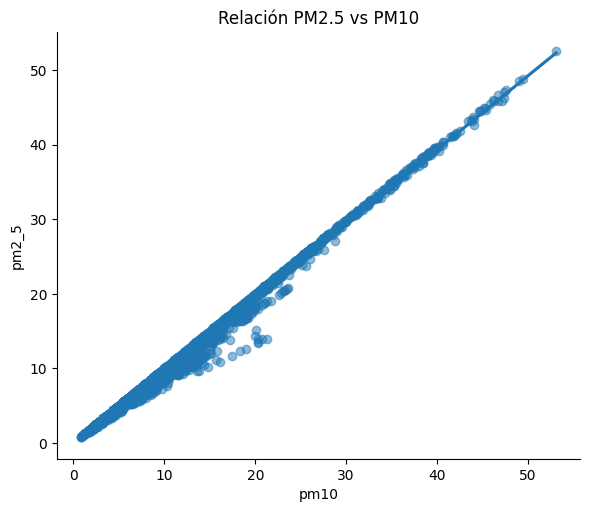

In [19]:
sns.lmplot(data=df_clean, x="pm10", y="pm2_5", aspect=1.2, scatter_kws={'alpha':0.5})
plt.title("Relación PM2.5 vs PM10")
plt.show()


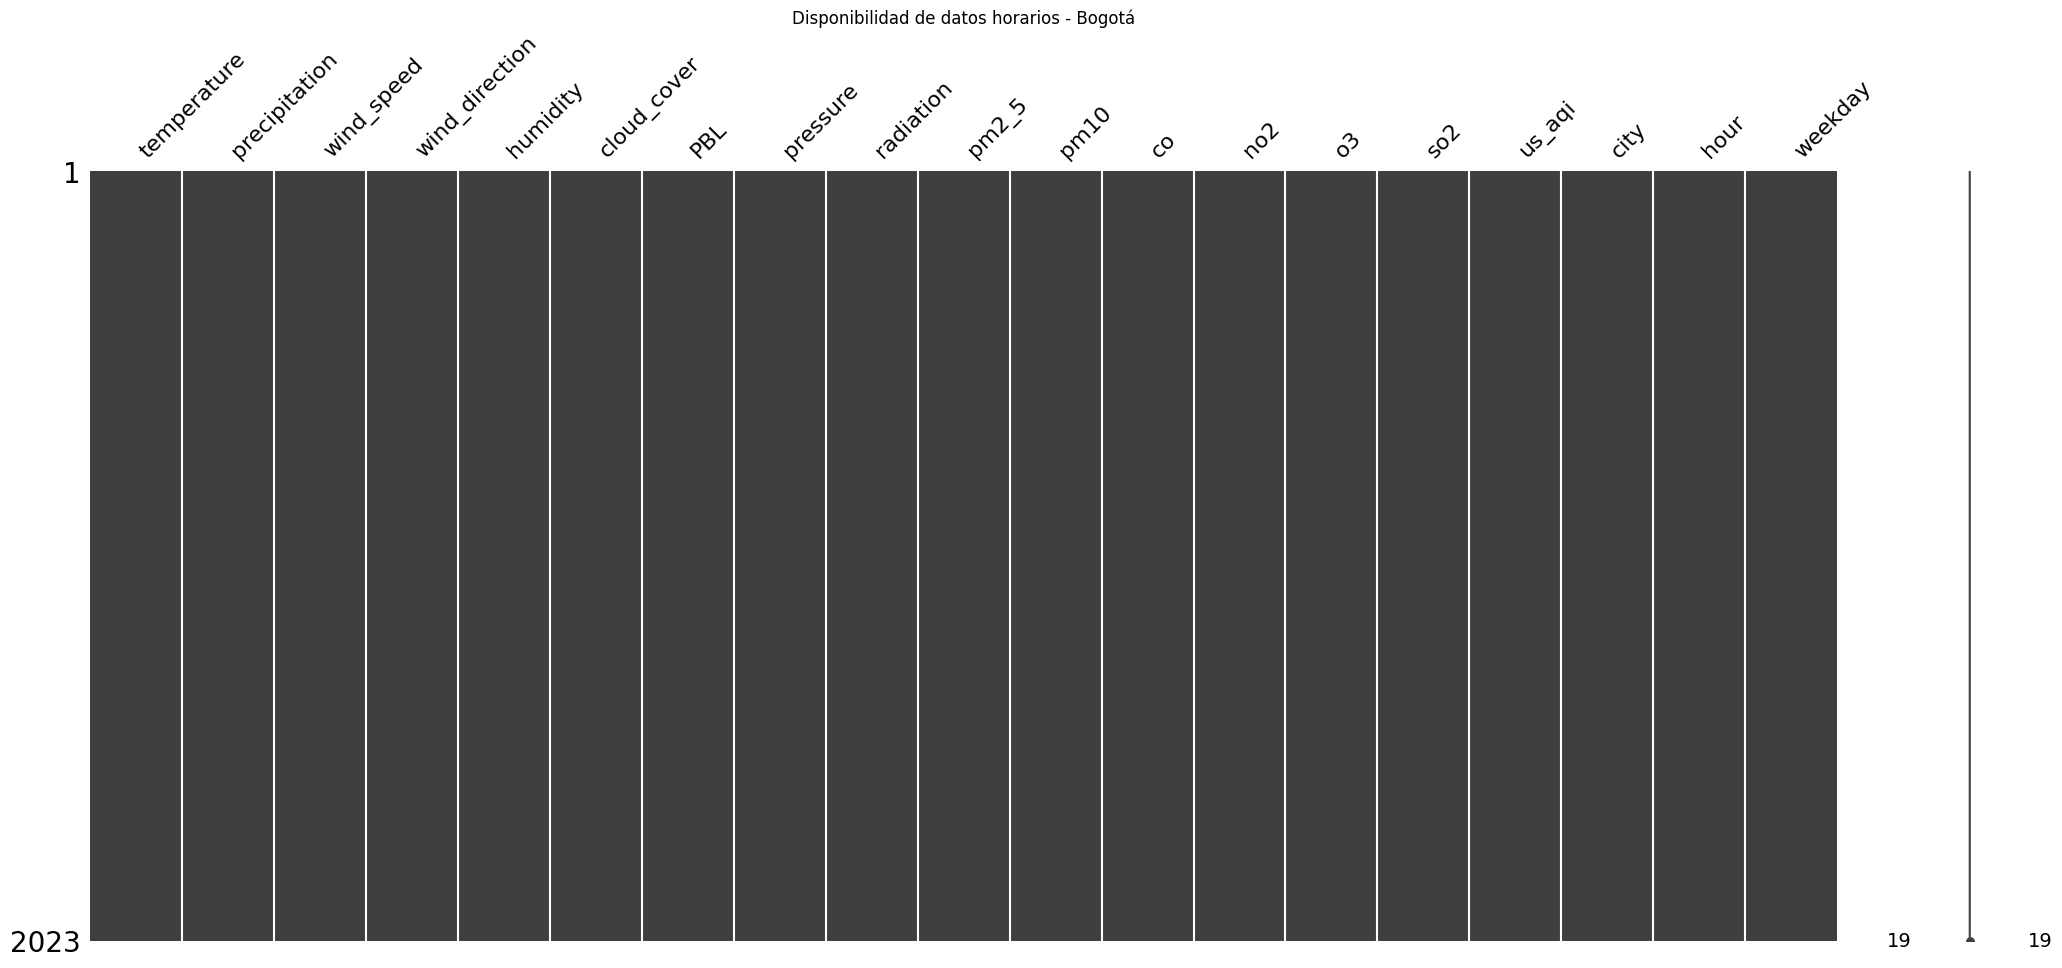

Valores nulos por variable:
temperature       0
precipitation     0
wind_speed        0
wind_direction    0
humidity          0
cloud_cover       0
PBL               0
pressure          0
radiation         0
pm2_5             0
pm10              0
co                0
no2               0
o3                0
so2               0
us_aqi            0
city              0
hour              0
weekday           0
dtype: int64


'\n Hallazgos esperados:\n- Variaciones diarias claras (picos matutinos y vespertinos de tráfico).\n- PM2.5 tiende a aumentar en horas nocturnas y fines de semana.\n- Distribución sesgada hacia valores bajos, con outliers durante episodios críticos.\n- Fuerte correlación inversa con la velocidad del viento y PBL.\n\n'

In [39]:
# D. Calidad de datos
msno.matrix(df_city)
plt.title(f"Disponibilidad de datos horarios - {ciudad}")
plt.show()

print("Valores nulos por variable:")
print(df_city.isna().sum())
# E. Hallazgos esperados (comentario guía)

"""
 Hallazgos esperados:
- Variaciones diarias claras (picos matutinos y vespertinos de tráfico).
- PM2.5 tiende a aumentar en horas nocturnas y fines de semana.
- Distribución sesgada hacia valores bajos, con outliers durante episodios críticos.
- Fuerte correlación inversa con la velocidad del viento y PBL.

"""

Pronóstico meteorológico

Código actualizado + análisis EDA

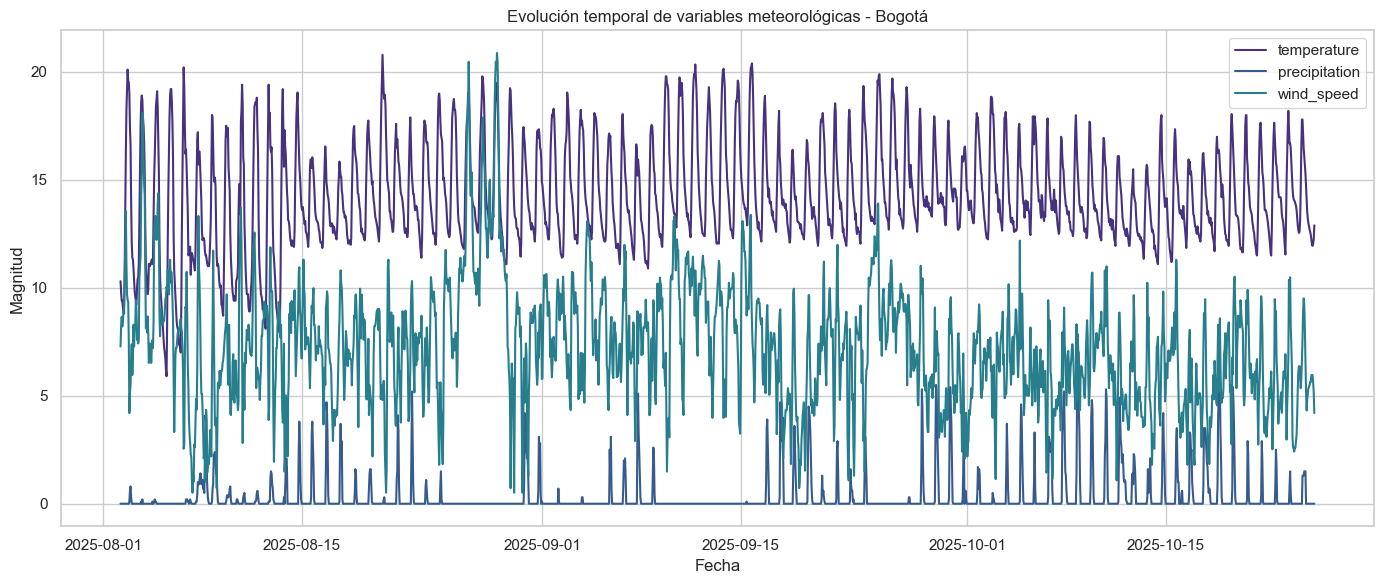

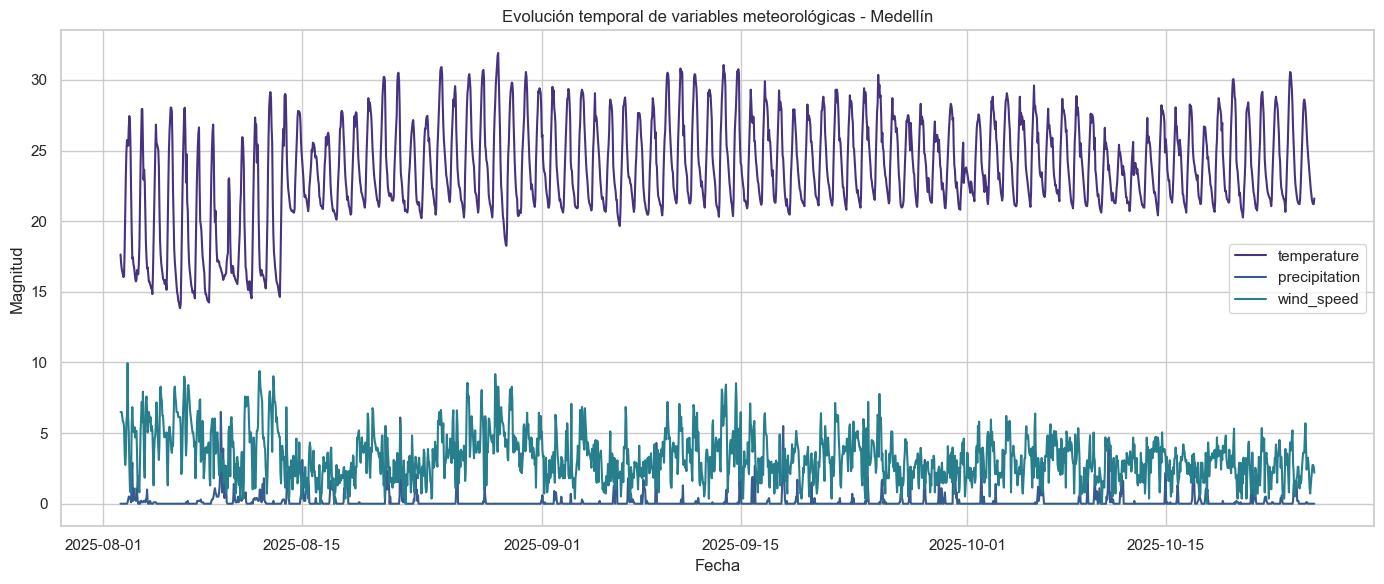

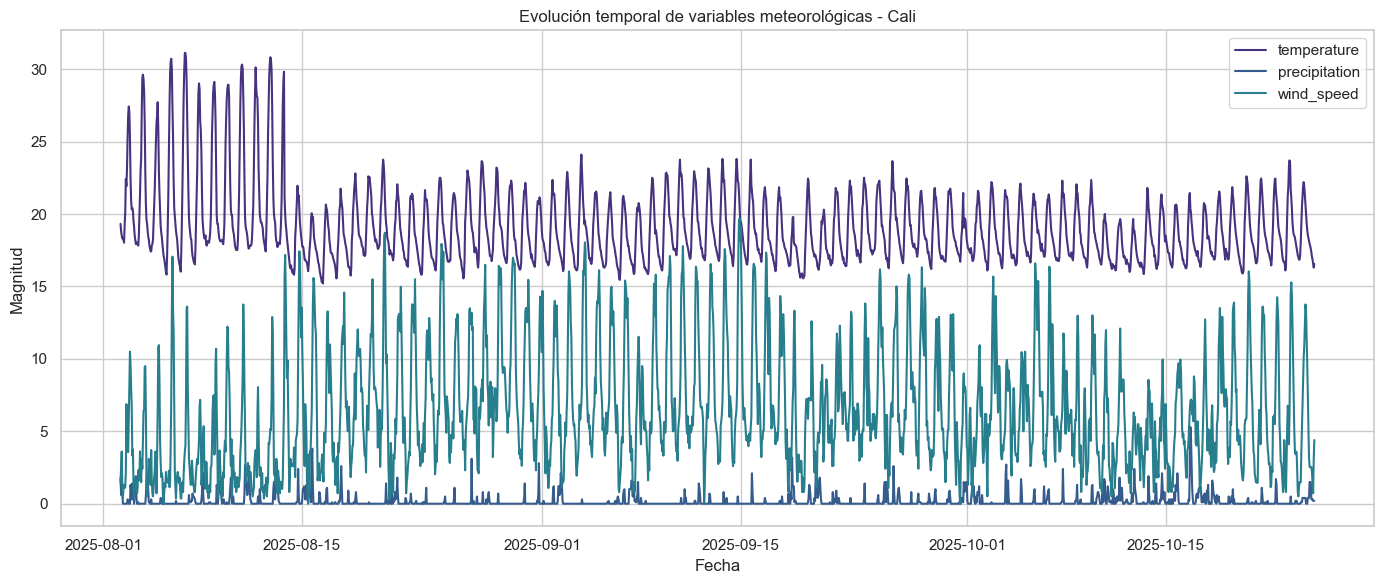

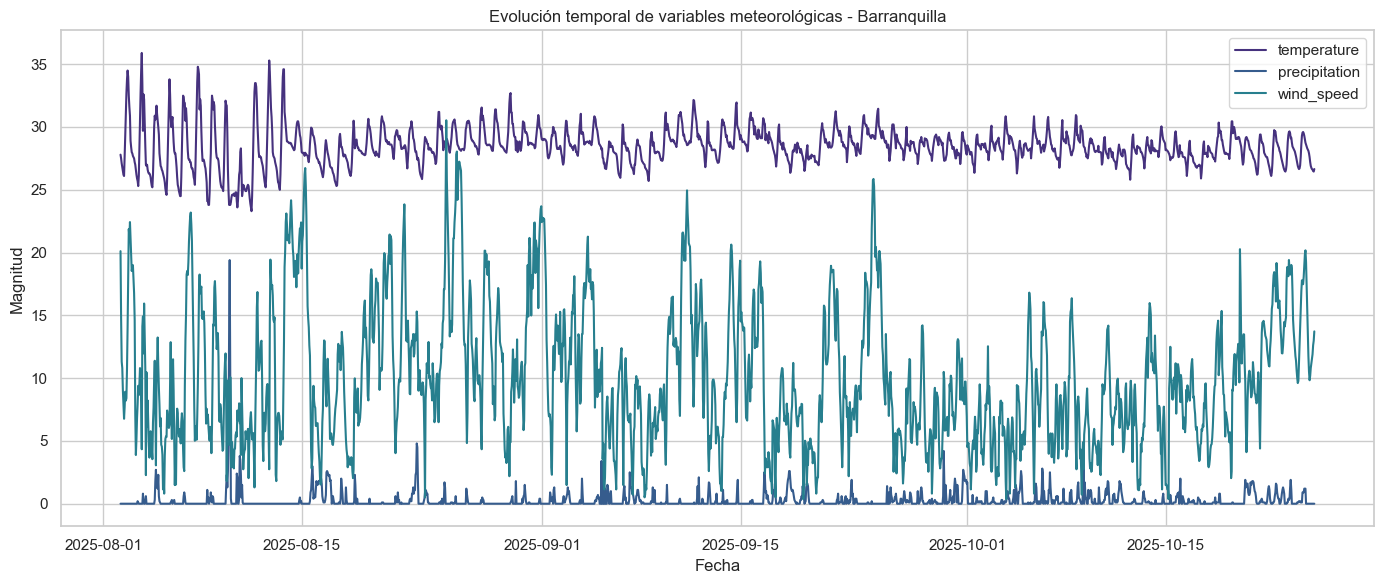

In [40]:
# A. Análisis temporal y estacional (por ciudad)

sns.set(style="whitegrid", palette="viridis")

ciudades_unicas = df_clean["city"].unique()

for ciudad in ciudades_unicas:
    df_city = df_clean[df_clean["city"] == ciudad]

    plt.figure(figsize=(14,6))
    for var in ["temperature","precipitation","wind_speed"]:
        plt.plot(df_city["date"], df_city[var], label=var)

    plt.title(f"Evolución temporal de variables meteorológicas - {ciudad}")
    plt.xlabel("Fecha")
    plt.ylabel("Magnitud")
    plt.legend()
    plt.tight_layout()
    plt.show()


Los gráficos, para cada ciudad, crea un gráfico temporal con tres líneas: temperatura, precipitación y velocidad del viento a lo largo del tiempo.

Bogotá: temperatura estable (8–20 °C), picos de lluvia en mar–may y sep–nov, viento moderado.

Barranquilla: temperatura casi constante (27–32 °C), lluvias fuertes entre , viento alto todo el año.

Cali: temperatura cálida (20–30 °C), lluvia frecuente ( oct–nov), viento moderado.

Medellín: temperatura estable (18–28 °C),  Presenta picos intermitentes, indicando lluvias frecuentes pero variables; algunos días sin lluvia, otros con eventos marcados., viento bajo.
Velocidad del viento: Generalmente baja (0–6 m/s), con fluctuaciones suaves a lo largo del tiempo.


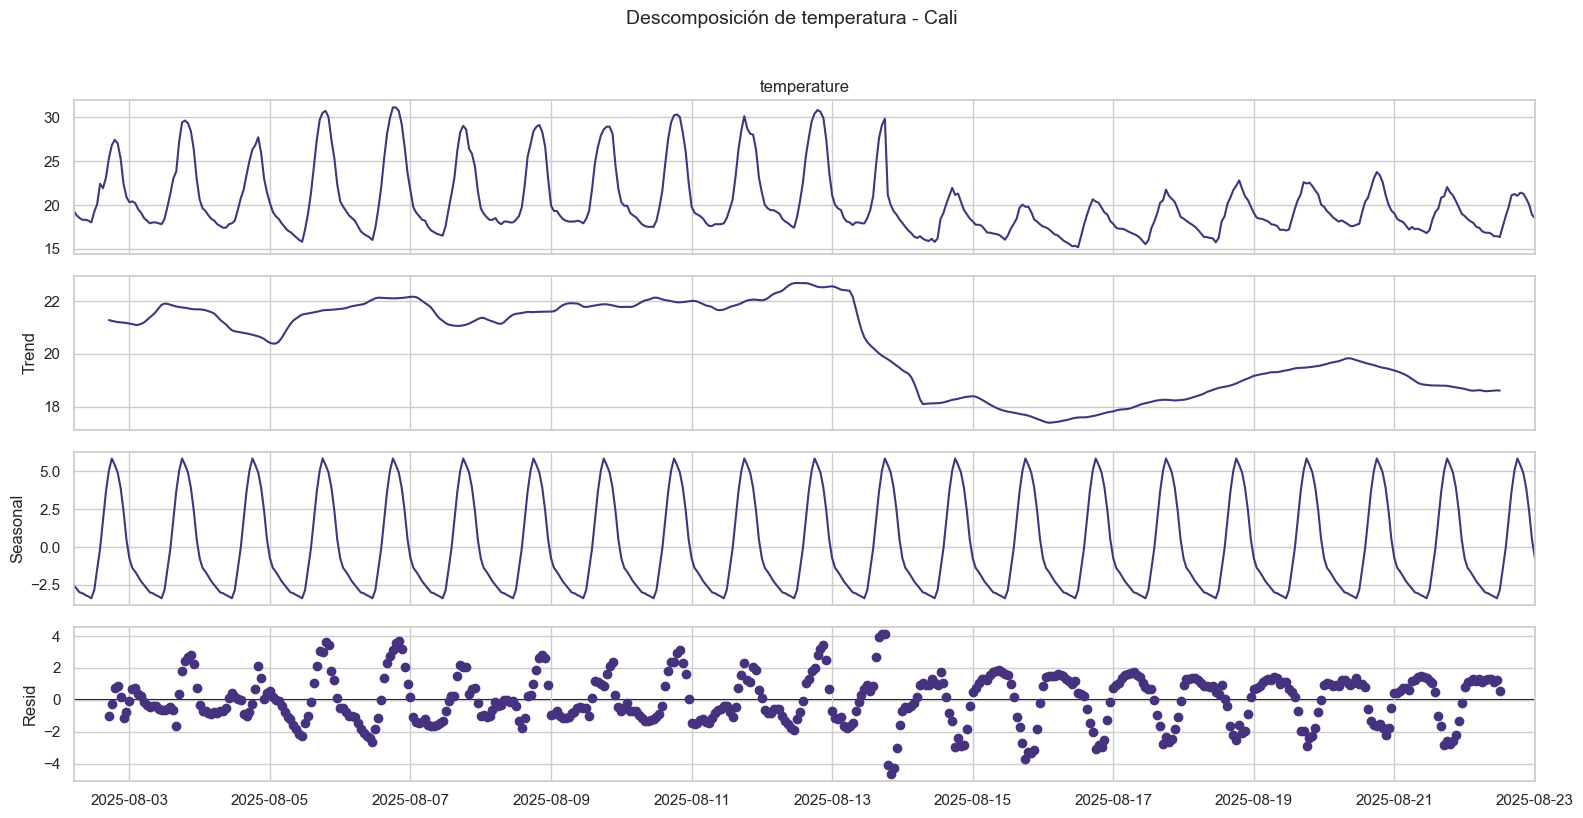

In [41]:
#Descomposición de la serie de temperatura (tendencia + estacionalidad + residuo)
city_example = "Cali"
df_city = df_clean[df_clean["city"] == city_example].set_index("date")

#Descomposición de los primeros 500 datos
decomp = seasonal_decompose(df_city["temperature"].iloc[:500], period=24)

#Crear gráfico
fig = decomp.plot()

#Aumentar el tamaño: ancho=16, alto=8 (puedes subir a 20 si quieres más largo)
fig.set_size_inches(16, 8)

#Título general
plt.suptitle(f"Descomposición de temperatura - {city_example}", y=1.02, fontsize=14)

#Ajustar márgenes para evitar solapamiento
plt.tight_layout()
plt.show()


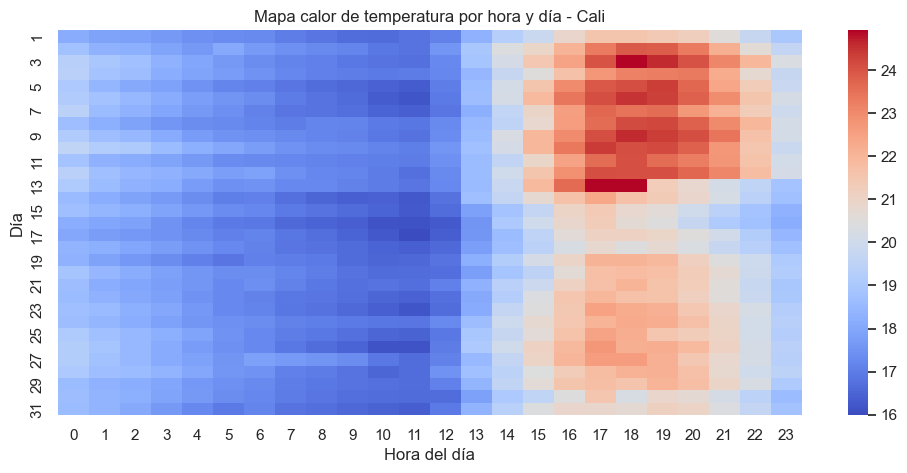

In [42]:
#  Heatmap hora x día (solo para temperatura)
df_city["hour"] = df_city.index.hour
df_city["day"] = df_city.index.day
pivot_temp = df_city.pivot_table(values="temperature", index="day", columns="hour")
plt.figure(figsize=(12,5))
sns.heatmap(pivot_temp, cmap="coolwarm")
plt.title(f"Mapa calor de temperatura por hora y día - {city_example}")
plt.xlabel("Hora del día")
plt.ylabel("Día")
plt.show()

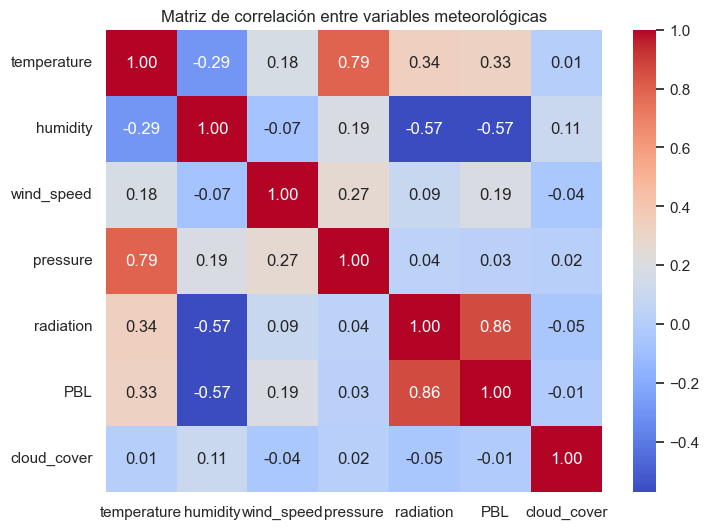

In [43]:
# B. Relación entre variables meteorológicas
vars_corr = ["temperature","humidity","wind_speed","pressure","radiation","PBL","cloud_cover"]
corr = df_clean[vars_corr].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables meteorológicas")
plt.show()


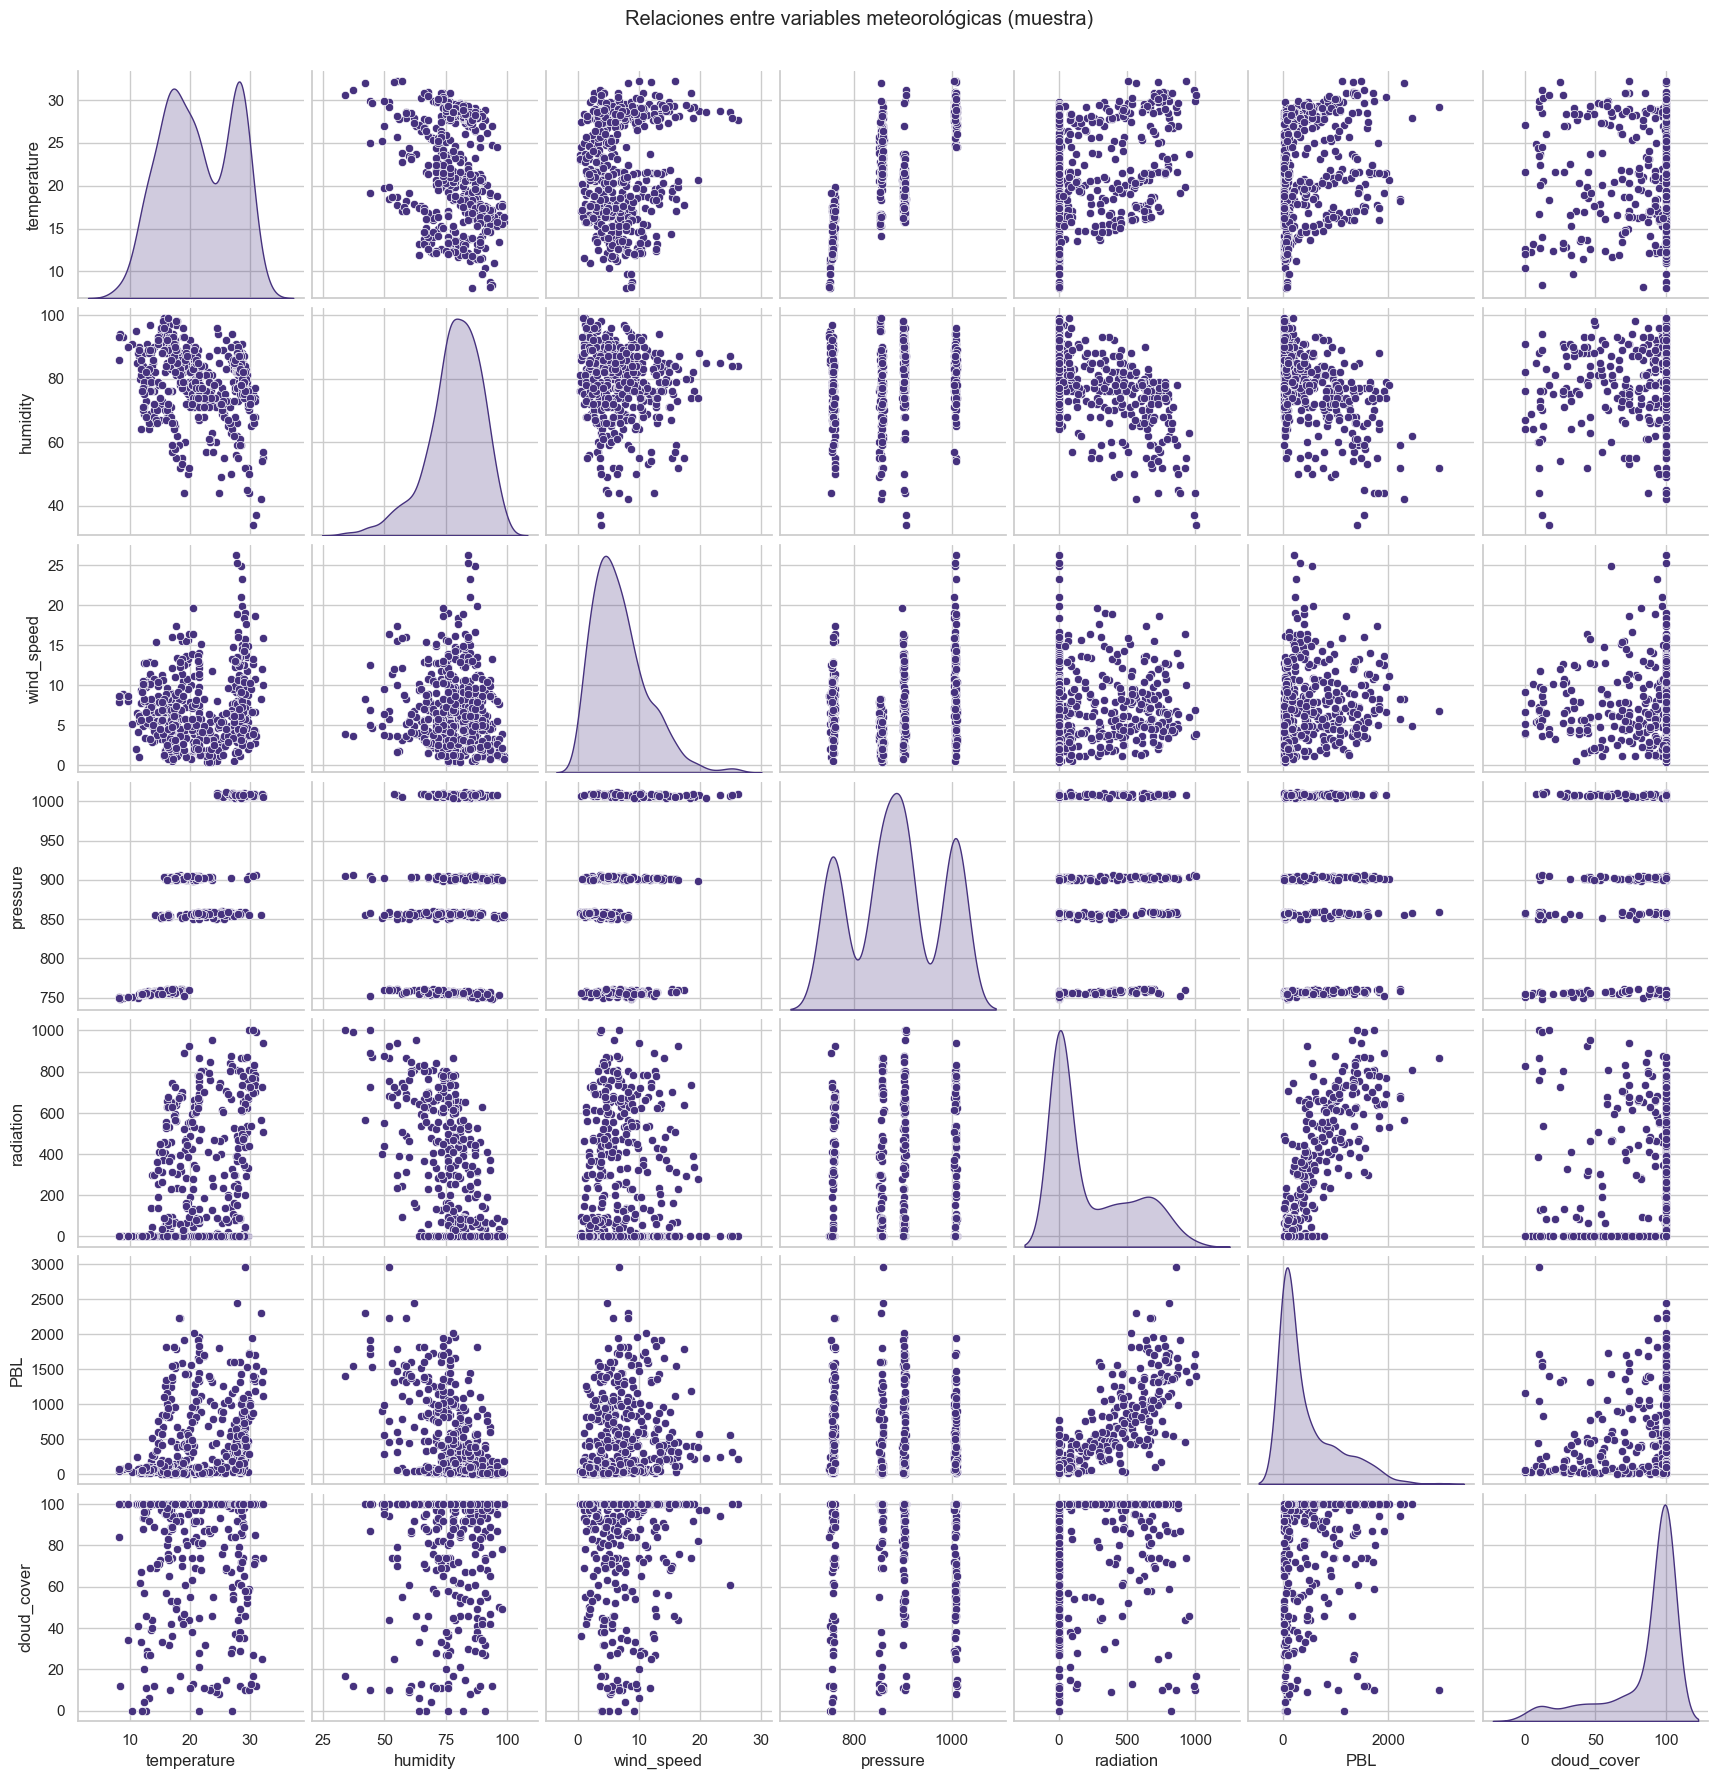

In [44]:
# Pairplot
sns.pairplot(df_clean[vars_corr].sample(500), diag_kind="kde")
plt.suptitle("Relaciones entre variables meteorológicas (muestra)", y=1.02)
plt.show()

Temperatura vs. Humedad: relación inversa clara → cuando aumenta la temperatura, la humedad tiende a disminuir.

Temperatura vs. Radiación: correlación positiva → a mayor radiación solar, mayor temperatura.

Humedad vs. Radiación: relación negativa → más radiación coincide con menor humedad.

Presión: valores agrupados en intervalos discretos (posible redondeo o niveles atmosféricos específicos).

Viento: dispersión amplia, sin correlación fuerte con otras variables.

Cobertura nubosa: concentra valores altos (mayoría de observaciones con cielo parcialmente o totalmente nublado).

PBL (capa límite planetaria): correlaciona débilmente con radiación y temperatura (a más radiación, mayor PBL).

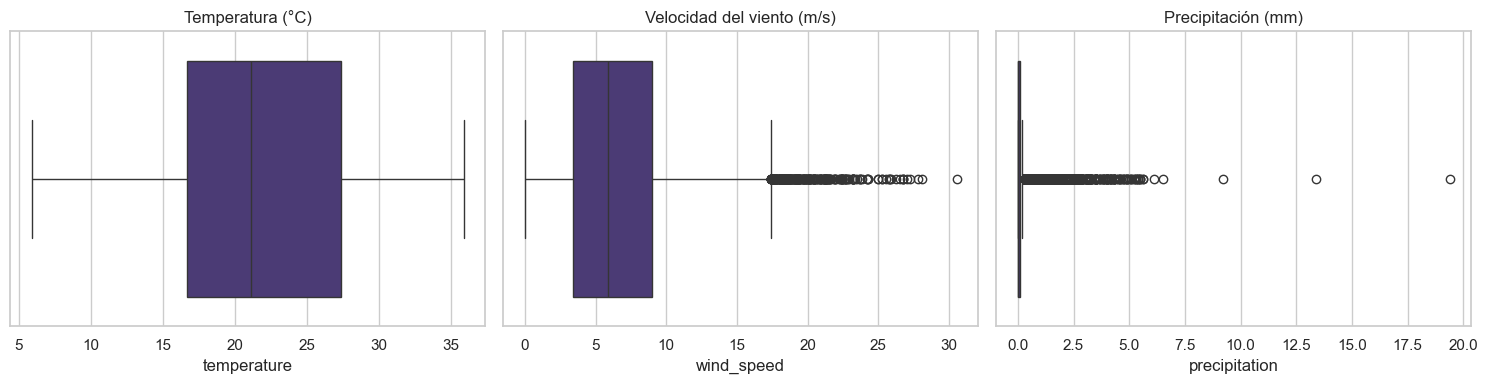

In [45]:
# C. Distribución y variabilidad

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(x="temperature", data=df_clean, ax=axes[0])
sns.boxplot(x="wind_speed", data=df_clean, ax=axes[1])
sns.boxplot(x="precipitation", data=df_clean, ax=axes[2])
axes[0].set_title("Temperatura (°C)")
axes[1].set_title("Velocidad del viento (m/s)")
axes[2].set_title("Precipitación (mm)")
plt.tight_layout()
plt.show()